In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import shap



/opt/anaconda3/envs/parkinsons_jcp/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
df = pd.read_csv('/Users/nabiha/parkinsons_model/data/parkinsons_disease_data.csv')
df.head(5)

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [8]:
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1)
df.head(5)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
0,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,9.283194,...,29.181289,1.572427,1,0,0,0,0,0,0,0
1,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,5.602470,...,12.332639,4.787551,0,1,0,1,0,1,0,1
2,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,9.929824,...,29.927783,2.130686,1,0,0,0,1,0,1,1
3,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,4.196189,...,21.304268,3.391288,1,1,1,0,0,0,1,1
4,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,9.363925,...,8.336364,3.200969,0,0,0,1,0,1,0,0


In [9]:
print('Shape:', df.shape)

Shape: (2105, 33)


In [10]:
print("\nData Types:")
df.dtypes


Data Types:


Age                           int64
Gender                        int64
Ethnicity                     int64
EducationLevel                int64
BMI                         float64
Smoking                       int64
AlcoholConsumption          float64
PhysicalActivity            float64
DietQuality                 float64
SleepQuality                float64
FamilyHistoryParkinsons       int64
TraumaticBrainInjury          int64
Hypertension                  int64
Diabetes                      int64
Depression                    int64
Stroke                        int64
SystolicBP                    int64
DiastolicBP                   int64
CholesterolTotal            float64
CholesterolLDL              float64
CholesterolHDL              float64
CholesterolTriglycerides    float64
UPDRS                       float64
MoCA                        float64
FunctionalAssessment        float64
Tremor                        int64
Rigidity                      int64
Bradykinesia                

In [11]:
print(df['Diagnosis'].value_counts())

Diagnosis
1    1304
0     801
Name: count, dtype: int64


In [12]:
print(df['Diagnosis'].value_counts(normalize=True).round(3) * 100)

Diagnosis
1    61.9
0    38.1
Name: proportion, dtype: float64


In [13]:
df.isnull().sum() > 0

Age                         False
Gender                      False
Ethnicity                   False
EducationLevel              False
BMI                         False
Smoking                     False
AlcoholConsumption          False
PhysicalActivity            False
DietQuality                 False
SleepQuality                False
FamilyHistoryParkinsons     False
TraumaticBrainInjury        False
Hypertension                False
Diabetes                    False
Depression                  False
Stroke                      False
SystolicBP                  False
DiastolicBP                 False
CholesterolTotal            False
CholesterolLDL              False
CholesterolHDL              False
CholesterolTriglycerides    False
UPDRS                       False
MoCA                        False
FunctionalAssessment        False
Tremor                      False
Rigidity                    False
Bradykinesia                False
PosturalInstability         False
SpeechProblems

In [14]:
df.describe()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
count,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,...,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,69.601900,0.492637,0.692637,1.337292,27.209493,0.296437,10.040413,5.016674,4.912901,6.996639,...,15.094314,4.989694,0.431829,0.252732,0.207601,0.138717,0.295012,0.245131,0.296912,0.619477
std,11.594511,0.500065,1.003827,0.895840,7.208099,0.456795,5.687014,2.890919,2.872115,1.753065,...,8.643014,2.933877,0.495449,0.434682,0.405686,0.345733,0.456156,0.430267,0.457006,0.485631
min,50.000000,0.000000,0.000000,0.000000,15.008333,0.000000,0.002228,0.004157,0.000011,4.000497,...,0.021191,0.001505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,0.000000,0.000000,1.000000,20.782176,0.000000,5.150278,2.455703,2.478503,5.488864,...,7.517160,2.415890,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,70.000000,0.000000,0.000000,1.000000,27.184571,0.000000,10.070337,5.031550,4.825187,6.929819,...,14.963574,4.983227,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,80.000000,1.000000,1.000000,2.000000,33.462452,1.000000,14.829565,7.512795,7.381487,8.558719,...,22.608362,7.484220,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,89.000000,1.000000,3.000000,3.000000,39.999887,1.000000,19.988866,9.995255,9.995864,9.999821,...,29.970107,9.992697,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
df.duplicated().sum()

np.int64(0)

Visualizations

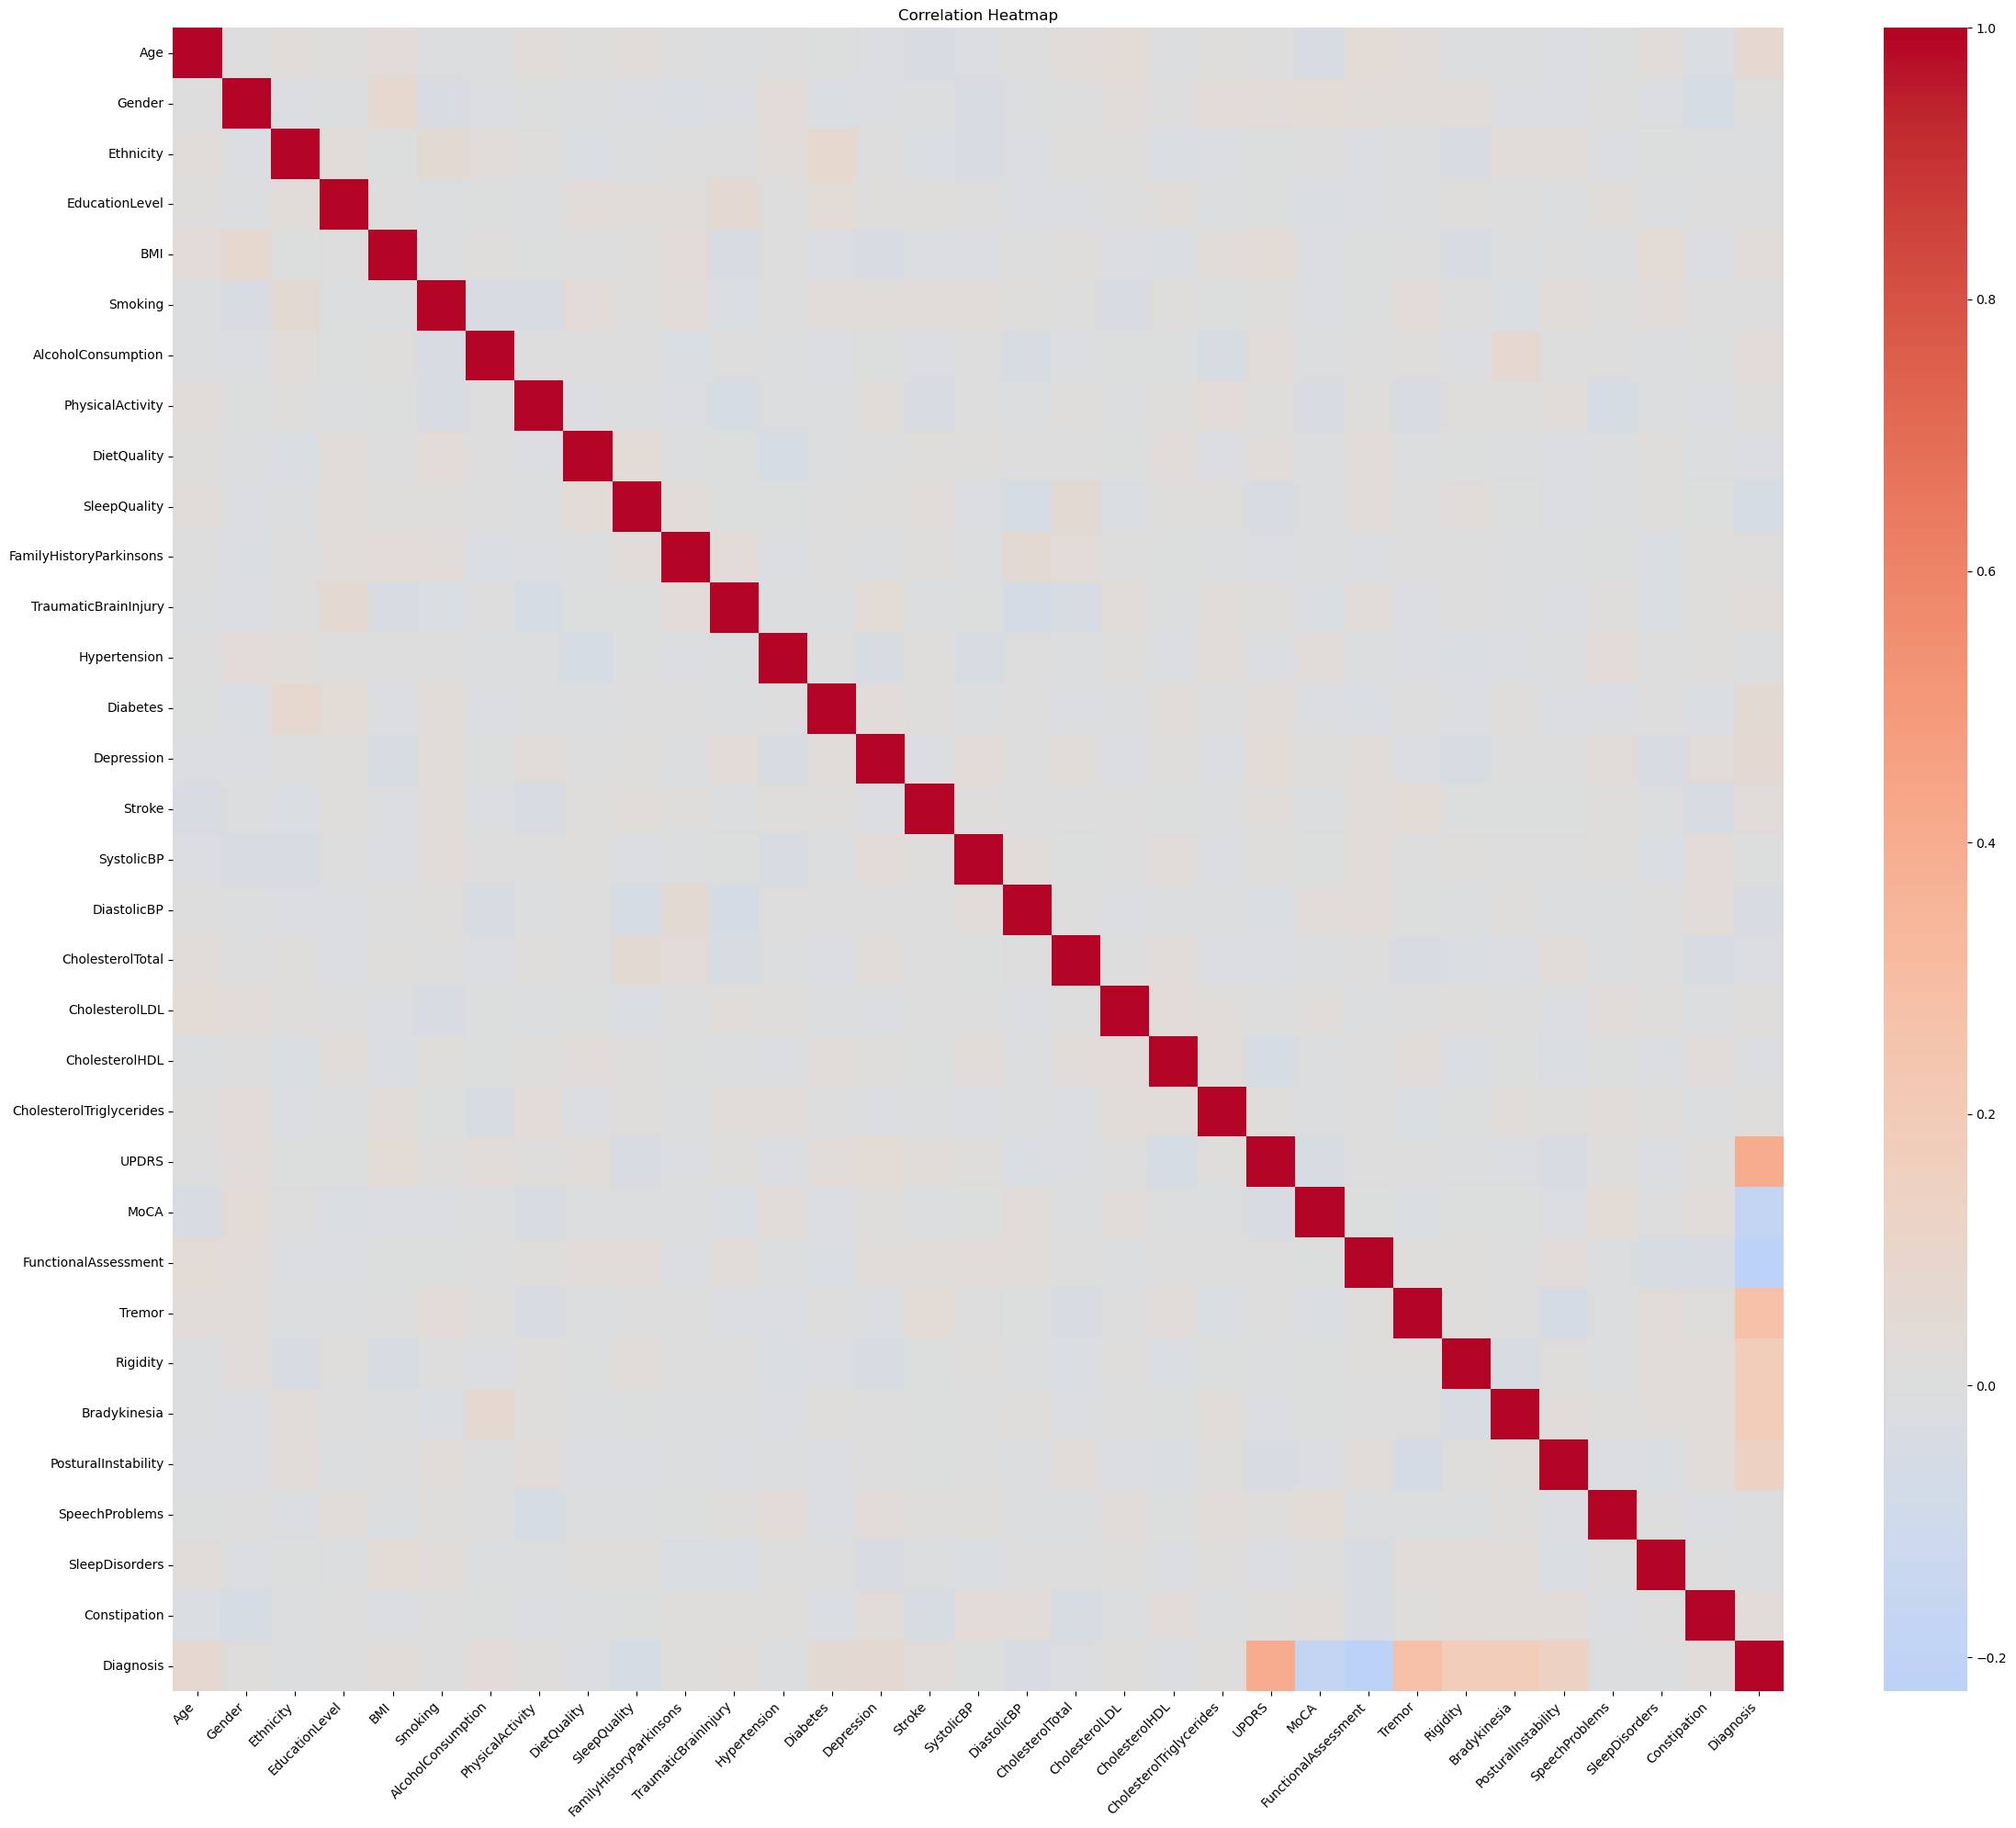

In [16]:
plt.figure(figsize=(24, 20))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0)
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [17]:
#The correlation heatmap shows weak linear correlations between most features and Diagnosis. This is expected given the synthetic nature of the dataset. Non-linear models like Random Forest may still find meaningful patterns that linear correlation cannot capture.

In [18]:
corr_with_diagnosis = df.corr()['Diagnosis'].drop('Diagnosis').sort_values(key=abs, ascending=False)
corr_with_diagnosis

UPDRS                       0.398006
Tremor                      0.274370
FunctionalAssessment       -0.225036
Rigidity                    0.185611
Bradykinesia                0.184042
MoCA                       -0.173104
PosturalInstability         0.147519
Age                         0.065344
Depression                  0.059080
Diabetes                    0.057067
SleepQuality               -0.043295
AlcoholConsumption          0.036699
BMI                         0.030114
DiastolicBP                -0.029074
Stroke                      0.028093
Constipation                0.025327
DietQuality                -0.022992
TraumaticBrainInjury        0.022964
CholesterolHDL             -0.019626
CholesterolTotal           -0.019001
Gender                      0.016835
CholesterolTriglycerides    0.015610
CholesterolLDL              0.014707
FamilyHistoryParkinsons     0.013363
PhysicalActivity            0.012940
SpeechProblems             -0.012220
Hypertension               -0.011587
S

<Axes: xlabel='Diagnosis', ylabel='UPDRS'>

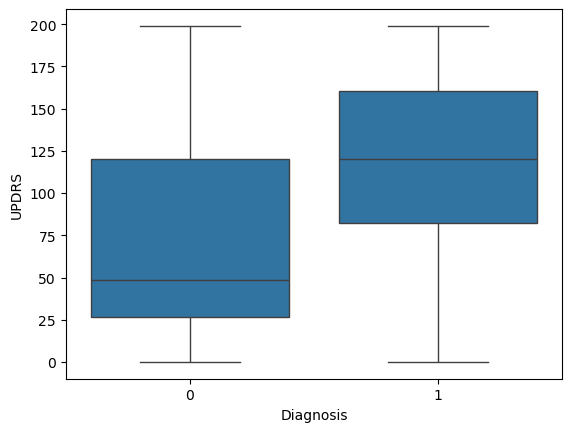

In [19]:
sns.boxplot(x='Diagnosis', y='UPDRS', data=df)
#PD patients show a notably higher median UPDRS score (~125) compared to healthy patients (~50)

<Axes: xlabel='Diagnosis', ylabel='FunctionalAssessment'>

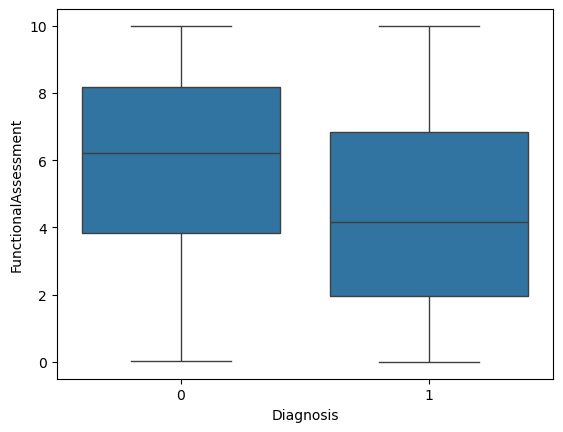

In [20]:
sns.boxplot(x='Diagnosis', y='FunctionalAssessment', data=df) 
# Healthy patients show a higher median FunctionalAssessment score (~6) compared to PD patients (~4), confirming that Parkinson's reduces ability to perform daily tasks, though the significant overlap between groups suggests this feature works best in combination with others.

<Axes: xlabel='Diagnosis', ylabel='MoCA'>

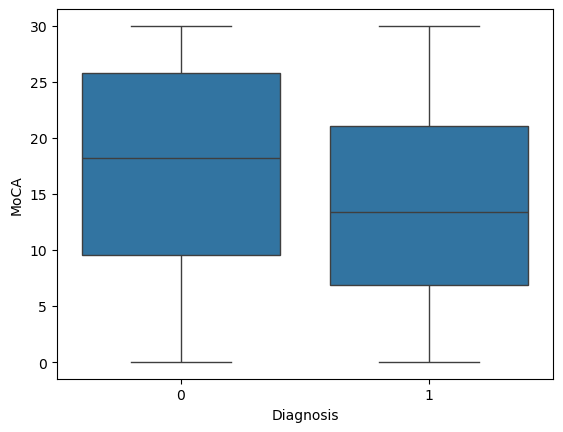

In [21]:
sns.boxplot(x='Diagnosis', y='MoCA', data=df)
# Healthy patients show a higher median MoCA score (~18) compared to PD patients (~14), suggesting that cognitive function is measurably lower in Parkinson's patients, consistent with the known neurodegenerative effects of the disease.

<Axes: xlabel='Tremor', ylabel='Diagnosis'>

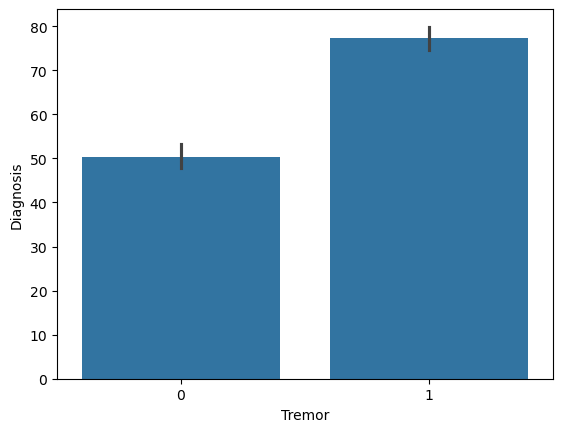

In [22]:
sns.barplot(x='Tremor', y='Diagnosis', data=df, estimator=lambda x: sum(x)/len(x)*100)
#Of all the patients that DO NOT have tremor, 50% have PD
#Of all the patients that DO have tremor, 77% have PD

#Having tremor increased liklihood of PD Diagnosis

<Axes: xlabel='Rigidity', ylabel='Diagnosis'>

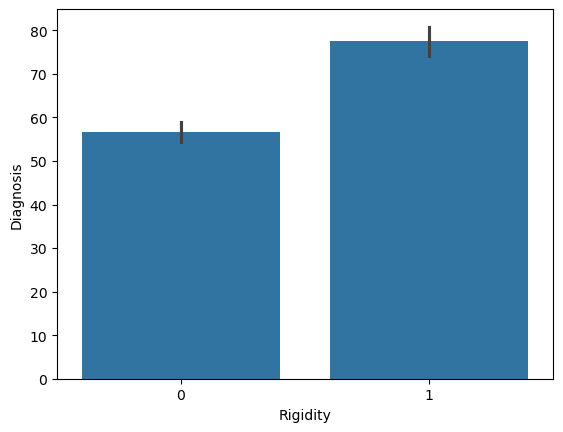

In [23]:
sns.barplot(x='Rigidity', y='Diagnosis', data=df, estimator= lambda x: sum(x)/len(x)*100)
#Of all the people that DO NOT experience rigidity, ~55% are diagnosed with PD
#Of all the people that DO experience rigidity, ~77% are diagnosed with PD

#Again, higher levels of Rigidity, has higher increased liklihood of PD Diagnosis 

<Axes: xlabel='Bradykinesia', ylabel='Diagnosis'>

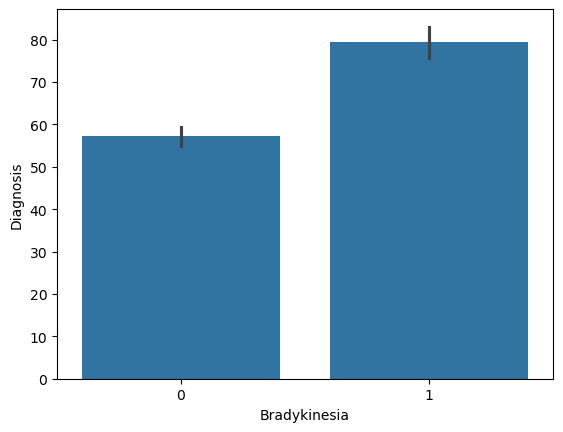

In [24]:
sns.barplot(x='Bradykinesia', y='Diagnosis', data=df, estimator=lambda x:sum(x)/len(x)*100)

<Axes: xlabel='PosturalInstability', ylabel='Diagnosis'>

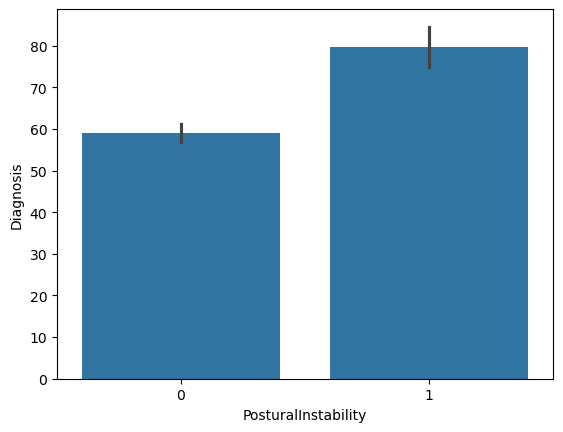

In [25]:
sns.barplot(x='PosturalInstability', y='Diagnosis', data=df, estimator=lambda x:sum(x)/len(x)*100)

All four motor symptoms show meaningfully higher PD rates when present, with Tremor showing the largest diagnostic gap, confirming these self-reportable symptoms as strong collective indicators of Parkinson's disease

In [26]:
X= df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=21, stratify=y)

print(X_train.shape)
print(X_test.shape)

(1684, 32)
(421, 32)


In [27]:
scaler = StandardScaler()                              # create once
X_train_scaled = scaler.fit_transform(X_train)        # fit AND transform train
X_test_scaled = scaler.transform(X_test)   
#The scaler learns from train (what's the mean, what's the std of each column), then applies those learned values to both train and test.

In [28]:
# Verifying scalers worked --> column values have a mean of 0, and std 1 to standardize
print(np.mean(X_train_scaled[:, 2])) 
print(np.std(X_train_scaled[:, 2]))  

-4.219374915440025e-17
0.9999999999999999


In [29]:
joblib.dump(scaler, '../models/clinical_scaler.pkl')
joblib.dump(X_train_scaled, '../models/X_train_scaled.pkl')
joblib.dump(X_test_scaled, '../models/X_test_scaled.pkl')
joblib.dump(y_train, '../models/y_train.pkl')
joblib.dump(y_test, '../models/y_test.pkl')

['../models/y_test.pkl']

In [30]:
estimator = LogisticRegression(max_iter=1000, random_state=21)
cv = StratifiedKFold(n_splits=5)

rfecv = RFECV(estimator=estimator, cv=cv, scoring='roc_auc')
rfecv.fit(X_train_scaled, y_train)

print("Optimal number of features:", rfecv.n_features_)
print("Selected features:", X_train.columns[rfecv.support_].tolist())


Optimal number of features: 13
Selected features: ['Age', 'DietQuality', 'TraumaticBrainInjury', 'Diabetes', 'Depression', 'UPDRS', 'MoCA', 'FunctionalAssessment', 'Tremor', 'Rigidity', 'Bradykinesia', 'PosturalInstability', 'SleepDisorders']


In [31]:
selected_features = X_train.columns[rfecv.support_].tolist()
joblib.dump(selected_features, '../models/selected_features.pkl')

['../models/selected_features.pkl']

In [32]:
X_train_selected = X_train_scaled[:, rfecv.support_]
X_test_selected = X_test_scaled[:, rfecv.support_]

print(X_train_selected.shape)  
print(X_test_selected.shape) 

(1684, 13)
(421, 13)


In [33]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_selected, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [34]:
y_pred_lr = lr.predict(X_test_selected)
y_prob_lr = lr.predict_proba(X_test_selected)[:, 1]

In [35]:
print("Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_lr), 3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.824

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       160
           1       0.85      0.87      0.86       261

    accuracy                           0.82       421
   macro avg       0.81      0.81      0.81       421
weighted avg       0.82      0.82      0.82       421

ROC AUC: 0.904

Confusion Matrix:
[[120  40]
 [ 34 227]]


In [36]:
#[[120  40] healthy patients: 120 correct, 40 wrongly flagged as PD (false positives)
 #[ 34 227]] PD patients: 227 correct, 34 missed (false negatives) 

Logistic regression baseline: 82.4% accuracy, 0.904 ROC AUC 
We want to focus on recall accuracy because then we reduce the amound of incorrectly undiagnosed PD patients 

In [37]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    scoring='roc_auc', 
    cv=5,
    verbose=2
)

grid_search.fit(X_train_selected, y_train)

print("Best params:", grid_search.best_params_)
print("Best ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=None, 

In [38]:
best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test_selected)
y_prob_rf = best_rf.predict_proba(X_test_selected)[:, 1]

print("Random Forest Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.929

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       160
           1       0.93      0.96      0.94       261

    accuracy                           0.93       421
   macro avg       0.93      0.92      0.92       421
weighted avg       0.93      0.93      0.93       421

ROC AUC: 0.956

Confusion Matrix:
[[141  19]
 [ 11 250]]


In [39]:
joblib.dump(best_rf, '../models/clinical_model.pkl')

['../models/clinical_model.pkl']

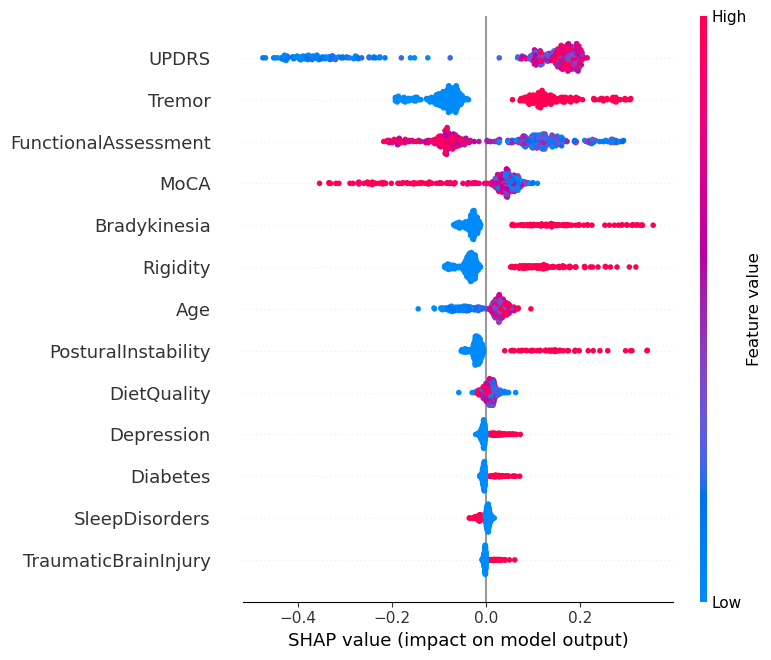

In [40]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_selected)
shap.summary_plot(shap_values[:, :, 1], X_test_selected, 
                  feature_names=selected_features)

In [41]:
joblib.dump(shap_values, '../models/shap_values.pkl')
joblib.dump(explainer, '../models/shap_explainer.pkl')

['../models/shap_explainer.pkl']

In [43]:


# 1. Class distribution
class_dist = pd.DataFrame({
    'Class': ['Healthy', 'Parkinson\'s'],
    'Count': [(df['Diagnosis']==0).sum(), (df['Diagnosis']==1).sum()]
})
class_dist.to_csv('../models/class_distribution.csv', index=False)

# 2. Feature importance (from Random Forest, easier than SHAP for dashboard)
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)
feature_importance.to_csv('../models/feature_importance.csv', index=False)

# 3. ROC data for clinical model
from sklearn.metrics import roc_curve
fpr_clinical, tpr_clinical, _ = roc_curve(y_test, y_prob_rf)
roc_clinical = pd.DataFrame({'FPR': fpr_clinical, 'TPR': tpr_clinical})
roc_clinical.to_csv('../models/roc_clinical.csv', index=False)

# 4. Confusion matrix for drawing model
# You'll need to load this from your 02_drawing notebook
# For now save clinical confusion matrix
from sklearn.metrics import confusion_matrix
cm_clinical = confusion_matrix(y_test, y_pred_rf)
cm_df = pd.DataFrame(cm_clinical, 
                      index=['Actual Healthy', 'Actual PD'],
                      columns=['Predicted Healthy', 'Predicted PD'])
cm_df.to_csv('../models/confusion_matrix.csv')


In [ ]:
# Export more data for enhanced dashboard

# Logistic regression metrics (you should still have y_pred_lr, y_prob_lr from Day 4)
model_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC AUC', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
})
model_comparison.to_csv('../models/model_comparison.csv', index=False)